# Production Sequencing — Beginner Training Notebook

This notebook builds up the core ideas behind a production-sequencing optimizer,
one small piece at a time. Every step is runnable and uses fake (synthetic) data
that behaves like a real manufacturing schedule, so nothing here depends on any
real company file.

**How to use this notebook:** run the cells top to bottom. After each step, try
changing a number (window size, number of rows, etc.) and re-run to see what
changes. That's more valuable than reading the code passively.

Steps in this notebook:
1. Load and look
2. Hardcode a couple of rules as functions
3. Visualize violations
4. Try one swap by hand
5. Keep-if-better search (basic loop)
6. Let the search escape dead ends
7. Write-back with openpyxl (formula safety)


## Step 1 — Load and look

Three ways to get data into this notebook are set up below:

- **`"synthetic"`** — a small fake schedule, generated on the spot. Always
  works, no file needed. This is the default so the notebook runs for anyone.
- **`"csv"`** — load your own `.csv` file.
- **`"excel"`** — load your own `.xlsx` file.

Set `DATA_SOURCE` in the cell below to whichever one you want, and if you're
using your own file, set `DATA_PATH` to point at it. The goal of this step is
just to get comfortable looking at the data — not to fix anything yet.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ------------------------- CONFIG -------------------------
DATA_SOURCE = "synthetic"   # one of: "synthetic", "csv", "excel"
DATA_PATH = ""               # only needed for "csv" or "excel", e.g. "/uploads/schedule.xlsx"
JOB_TYPE_COLUMN = "job_type"  # the column name that holds the job type, once loaded
# ------------------------------------------------------------


In [2]:
def make_synthetic_schedule(n_rows=40):
    job_types = ["A", "B", "C", "D"]
    frame = pd.DataFrame({
        "row_id": range(1, n_rows + 1),
        "job_type": rng.choice(job_types, size=n_rows, p=[0.4, 0.3, 0.2, 0.1]),
    })
    return frame


def load_csv_schedule(path):
    frame = pd.read_csv(path)
    return frame


def load_excel_schedule(path, sheet_name=0):
    # sheet_name=0 means "the first sheet" — pass a sheet name (a string)
    # instead if your file has multiple sheets and you need a specific one
    frame = pd.read_excel(path, sheet_name=sheet_name)
    return frame


if DATA_SOURCE == "synthetic":
    df = make_synthetic_schedule(n_rows=40)

elif DATA_SOURCE == "csv":
    if not DATA_PATH:
        raise ValueError("Set DATA_PATH to your .csv file before running with DATA_SOURCE='csv'")
    df = load_csv_schedule(DATA_PATH)

elif DATA_SOURCE == "excel":
    if not DATA_PATH:
        raise ValueError("Set DATA_PATH to your .xlsx file before running with DATA_SOURCE='excel'")
    df = load_excel_schedule(DATA_PATH)

else:
    raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE!r}")

print(f"Loaded {len(df)} rows from source: {DATA_SOURCE}")
df.head(10)


Loaded 40 rows from source: synthetic


,row_id,job_type
0,1,C
1,2,B
2,3,C
3,4,B
4,5,A
5,6,D
6,7,C
7,8,C
8,9,A
9,10,B


**If you loaded your own CSV or Excel file:** the rest of this notebook
expects a column called `job_type` (or whatever you set `JOB_TYPE_COLUMN` to
above). If your real column is named something else — e.g. `Job Type` or
`part_no` — rename it now so the rest of the notebook doesn't need to change:


In [3]:
if JOB_TYPE_COLUMN != "job_type":
    df = df.rename(columns={JOB_TYPE_COLUMN: "job_type"})
    print(f"Renamed '{JOB_TYPE_COLUMN}' -> 'job_type'")
else:
    print("No rename needed.")


No rename needed.


**A note if you're loading a real Excel file with formula columns:**
`pd.read_excel()` only ever gives you the *last calculated value* of a
formula, never the formula itself — so at this stage you can't yet tell which
columns are formulas just by looking at what pandas loaded. That distinction
matters a lot later (Step 7), but for now, just looking and exploring is
enough.


In [4]:
# a "computed" column, standing in for an Excel formula column.
# In the real project, columns like this must NEVER be written to directly —
# they are derived from other columns. Here it's just: running count of how
# many times this job_type has appeared so far. If you loaded your own file
# and it already has a similar column, feel free to skip adding this one.
def compute_running_count(frame):
    return frame.groupby("job_type").cumcount() + 1

if "running_count_computed" not in df.columns:
    df["running_count_computed"] = compute_running_count(df)

df.head(10)


,row_id,job_type,running_count_computed
0,1,C,1
1,2,B,1
2,3,C,2
3,4,B,2
4,5,A,1
5,6,D,1
6,7,C,3
7,8,C,4
8,9,A,2
9,10,B,3


Look at `.dtypes` and skim a few rows. Ask yourself: if I changed `job_type`
on one row, would `running_count_computed` still be correct? (It wouldn't —
that's exactly the kind of column you must recompute, never hand-edit, once we
get to real files later.)


In [5]:
df.dtypes


row_id                    int64
job_type                    str
running_count_computed    int64
dtype: object

## Step 2 — Hardcode 2-3 rules as functions

Real scheduling rules are just constraints like *"don't put more than 2 of the
same job type in any window of 5 rows in a row."* We'll write these as plain
functions that take the DataFrame and return a list of row indices that
violate the rule, plus a count.

No configuration system yet — just literal numbers baked into the function.
Get the logic right first.


In [6]:
def rule_window_count(frame, job_type, window=5, max_count=2):
    """Violation if more than `max_count` of `job_type` appear in any
    rolling window of `window` consecutive rows."""
    is_type = (frame["job_type"] == job_type).astype(int)
    rolling = is_type.rolling(window=window, min_periods=1).sum()
    violating_rows = frame.index[rolling > max_count].tolist()
    return violating_rows


def rule_no_adjacent_repeat(frame, job_type):
    """Violation if the same job_type appears twice in a row."""
    same_as_prev = (frame["job_type"] == frame["job_type"].shift(1))
    is_type = (frame["job_type"] == job_type)
    violating_rows = frame.index[same_as_prev & is_type].tolist()
    return violating_rows


def count_violations(frame):
    total = 0
    total += len(rule_window_count(frame, job_type="A", window=5, max_count=2))
    total += len(rule_no_adjacent_repeat(frame, job_type="B"))
    return total


print("Total violations in current schedule:", count_violations(df))


Total violations in current schedule: 7


Try changing `window` or `max_count` in `rule_window_count` and re-run.
Notice how the violation count changes — this is the same number the search
will later try to push down to zero (or as low as possible).


## Step 3 — Visualize violations

A number on its own ("12 violations") doesn't tell you much. Seeing *where*
they cluster in the sequence is far more useful — both for you as a beginner,
and for a planner using the real tool.


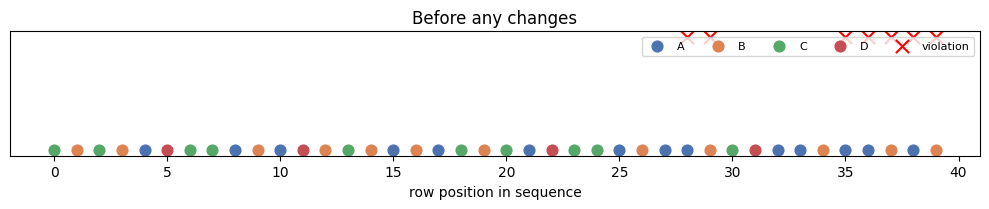

In [7]:
def plot_violations(frame, title="Violation locations"):
    fig, ax = plt.subplots(figsize=(10, 2.2))

    colors = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868", "D": "#C44E52"}
    for job_type, color in colors.items():
        mask = frame["job_type"] == job_type
        ax.scatter(frame.index[mask], [0] * mask.sum(), color=color, label=job_type, s=60)

    win_rows = rule_window_count(frame, job_type="A", window=5, max_count=2)
    adj_rows = rule_no_adjacent_repeat(frame, job_type="B")
    bad_rows = sorted(set(win_rows) | set(adj_rows))
    ax.scatter(bad_rows, [0.15] * len(bad_rows), color="red", marker="x", s=90, label="violation")

    ax.set_yticks([])
    ax.set_xlabel("row position in sequence")
    ax.set_title(title)
    ax.legend(loc="upper right", ncol=5, fontsize=8)
    plt.tight_layout()
    plt.show()

plot_violations(df, "Before any changes")


## Step 4 — Try one swap by hand

Before writing any loop, do the most basic operation once, by hand: swap two
rows, recompute violations, and compare. This is the single move that the
whole search will repeat thousands of times later — once you've done it
manually, the loop in the next step is just "do this, but automatically."


In [8]:
def swap_rows(frame, i, j):
    new_frame = frame.copy()
    new_frame.loc[[i, j], "job_type"] = new_frame.loc[[j, i], "job_type"].values
    # the computed column must be recalculated after any reordering —
    # never copied along with the swap
    new_frame["running_count_computed"] = compute_running_count(new_frame)
    return new_frame


before_score = count_violations(df)
i, j = 3, 17
df_try = swap_rows(df, i, j)
after_score = count_violations(df_try)

print(f"Before swap: {before_score} violations")
print(f"After swapping rows {i} and {j}: {after_score} violations")


Before swap: 7 violations
After swapping rows 3 and 17: 8 violations


Try a few different `(i, j)` pairs above and re-run. Some swaps help, some
don't, some do nothing. That randomness is exactly why the next step tries
many swaps rather than guessing by hand.


## Step 5 — Keep-if-better search (basic loop)

Now automate step 4: repeatedly try a random swap, keep it if it improves the
score, undo it otherwise. Plot the violation count over iterations.

This simple loop already gets decent results on its own.


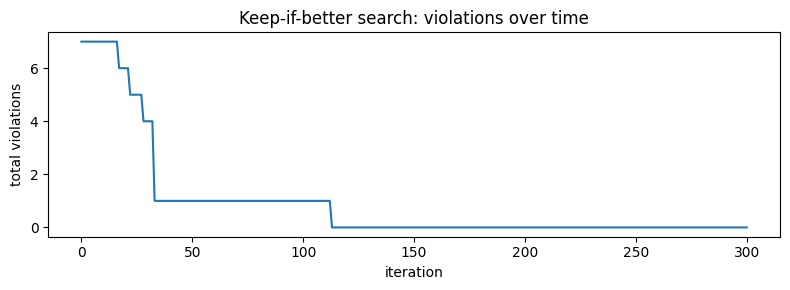

Starting violations: 7
Final violations: 0


In [9]:
def keep_if_better_search(frame, n_iterations=300, seed=0):
    rng_local = np.random.default_rng(seed)
    current = frame.copy()
    current_score = count_violations(current)
    history = [current_score]

    n_rows = len(current)
    for _ in range(n_iterations):
        i, j = rng_local.integers(0, n_rows, size=2)
        if i == j:
            history.append(current_score)
            continue

        candidate = swap_rows(current, i, j)
        candidate_score = count_violations(candidate)

        if candidate_score <= current_score:
            current = candidate
            current_score = candidate_score

        history.append(current_score)

    return current, history


result_df, history = keep_if_better_search(df, n_iterations=300)

plt.figure(figsize=(8, 3))
plt.plot(history)
plt.xlabel("iteration")
plt.ylabel("total violations")
plt.title("Keep-if-better search: violations over time")
plt.tight_layout()
plt.show()

print("Starting violations:", history[0])
print("Final violations:", history[-1])


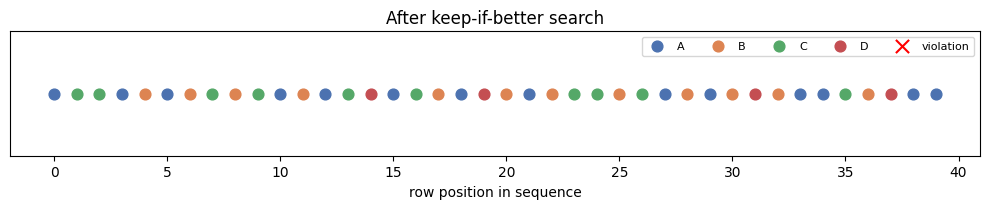

In [10]:
plot_violations(result_df, "After keep-if-better search")


Run the cell above a few times with different `seed` values. Notice the
final score sometimes gets stuck higher than other times — that's the "dead
end" problem the next step addresses.


## Step 6 — Let the search escape dead ends

The problem with "only keep if better": once every single swap available makes
things worse, the search freezes, even if a better arrangement exists a few
swaps away.

The fix: **occasionally accept a swap that makes things slightly worse, on
purpose** — and do this less and less often as the search goes on, so it
explores early and settles down later.

That one idea — sometimes say yes to a worse move, but say yes less often over
time — is the entire concept. (If you look this up later, it's called
*Simulated Annealing*, but the name doesn't matter for understanding it.)


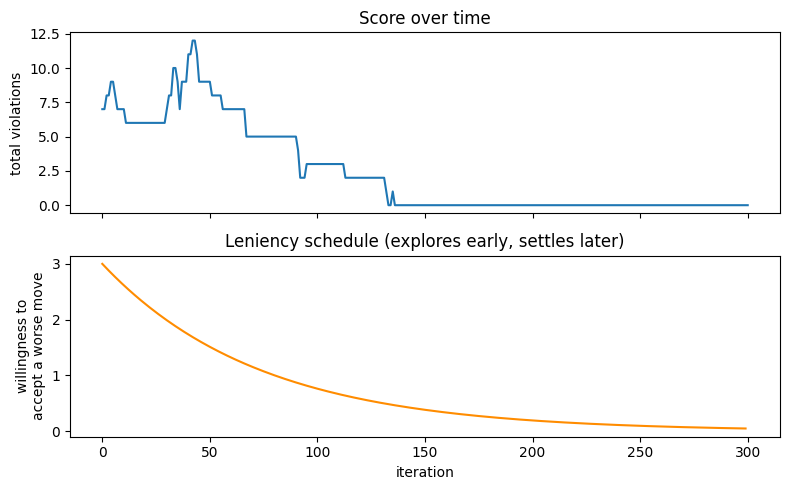

Best violations found: 0


In [11]:
def escape_search(frame, n_iterations=300, seed=0,
                   start_leniency=3.0, end_leniency=0.05):
    """
    start_leniency / end_leniency control how willing the search is to accept
    a worse swap. Higher = more willing. It decreases smoothly from
    start_leniency down to end_leniency over the run.
    """
    rng_local = np.random.default_rng(seed)
    current = frame.copy()
    current_score = count_violations(current)

    best = current.copy()
    best_score = current_score

    history_score = [current_score]
    history_leniency = []

    n_rows = len(current)
    for step in range(n_iterations):
        # leniency decays from start_leniency to end_leniency
        progress = step / max(n_iterations - 1, 1)
        leniency = start_leniency * ((end_leniency / start_leniency) ** progress)
        history_leniency.append(leniency)

        i, j = rng_local.integers(0, n_rows, size=2)
        if i == j:
            history_score.append(current_score)
            continue

        candidate = swap_rows(current, i, j)
        candidate_score = count_violations(candidate)
        delta = candidate_score - current_score

        if delta <= 0:
            accept = True
        else:
            # willing to accept a worse move sometimes; less likely as
            # leniency shrinks, and less likely the worse the move is
            accept_probability = np.exp(-delta / max(leniency, 1e-9))
            accept = rng_local.random() < accept_probability

        if accept:
            current = candidate
            current_score = candidate_score
            if current_score < best_score:
                best = current.copy()
                best_score = current_score

        history_score.append(current_score)

    return best, best_score, history_score, history_leniency


best_df, best_score, hist_score, hist_leniency = escape_search(df, n_iterations=300)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(hist_score)
axes[0].set_ylabel("total violations")
axes[0].set_title("Score over time")

axes[1].plot(hist_leniency, color="darkorange")
axes[1].set_ylabel("willingness to\naccept a worse move")
axes[1].set_xlabel("iteration")
axes[1].set_title("Leniency schedule (explores early, settles later)")

plt.tight_layout()
plt.show()

print("Best violations found:", best_score)


Compare `best_score` here against the final score from Step 5's
keep-if-better search — run both a few times with different seeds. The
escape-search version should find equal or better results more consistently,
because it isn't permanently stuck once it hits a dead end.

Try changing `start_leniency` (how adventurous it is early on) and see how
that changes the shape of the score curve.


## Step 7 — Write-back with openpyxl (formula safety)

Everything so far only lived in memory. Now: what happens when you save
results back to an Excel file that has real formula columns?

First, let's see the failure mode on purpose, using a tiny fake "formula
column" written with `openpyxl` — not `pandas.to_excel()`, which cannot tell
the difference between a formula and a value.


In [12]:
import openpyxl
from openpyxl.utils import get_column_letter

demo_path = "demo_schedule.xlsx"

wb = openpyxl.Workbook()
ws = wb.active
ws.title = "schedule"

ws["A1"] = "row_id"
ws["B1"] = "job_type"
ws["C1"] = "running_count_formula"  # this column will be a REAL Excel formula

for idx in range(2, 12):
    ws[f"A{idx}"] = idx - 1
    ws[f"B{idx}"] = ["A", "B", "A", "C", "B", "A", "D", "B", "A", "C"][idx - 2]
    # COUNTIF formula: how many times this job_type has appeared up to this row
    ws[f"C{idx}"] = f'=COUNTIF(B$2:B{idx}, B{idx})'

wb.save(demo_path)
print("Saved demo file with a real Excel formula in column C.")


Saved demo file with a real Excel formula in column C.


Now watch what happens if we "fix" the schedule the naive way — read it
with pandas, reorder rows, and write the whole thing back with
`DataFrame.to_excel()`.


In [13]:
demo_df = pd.read_excel(demo_path)
print("What pandas sees in the formula column (already evaluated, not a formula):")
print(demo_df)

# reorder rows the naive way and save with to_excel
shuffled = demo_df.sample(frac=1, random_state=1).reset_index(drop=True)
naive_out_path = "demo_schedule_naive_overwrite.xlsx"
shuffled.to_excel(naive_out_path, index=False)

# re-open with openpyxl and check column C
check_wb = openpyxl.load_workbook(naive_out_path)
check_ws = check_wb.active
print()
print("Column C after naive to_excel() overwrite (should be a formula, is it?):")
for row in range(2, 6):
    print(f"  C{row}:", check_ws[f"C{row}"].value)


What pandas sees in the formula column (already evaluated, not a formula):
   row_id job_type  running_count_formula
0       1        A                    NaN
1       2        B                    NaN
2       3        A                    NaN
3       4        C                    NaN
4       5        B                    NaN
5       6        A                    NaN
6       7        D                    NaN
7       8        B                    NaN
8       9        A                    NaN
9      10        C                    NaN

Column C after naive to_excel() overwrite (should be a formula, is it?):
  C2: None
  C3: None
  C4: None
  C5: None


Column C is now a plain number, not a formula — `to_excel()` silently
wrote pandas' evaluated value over what used to be a live formula. In a real
plant file, this is exactly how row references get corrupted after a reorder:
the formula is gone, and nothing tells you it happened.

Now the safe way: keep a list of which columns are formulas
(`EXCLUDE_COLUMNS` in the real project), edit the *original* workbook in
place with `openpyxl`, only touch literal columns, and leave every formula
cell completely untouched.


In [14]:
EXCLUDE_COLUMNS = {"running_count_formula"}  # never write to these

safe_wb = openpyxl.load_workbook(demo_path)
safe_ws = safe_wb.active

header = [cell.value for cell in safe_ws[1]]
col_letters = {name: get_column_letter(idx + 1) for idx, name in enumerate(header)}

new_order = [10, 3, 7, 1, 9, 2, 8, 4, 6, 5]  # a hand-picked new row order, 1-indexed

# read current literal values for every row we might move
literal_cols = [c for c in header if c not in EXCLUDE_COLUMNS]
original_rows = {}
for i in range(1, 11):
    excel_row = i + 1
    original_rows[i] = {col: safe_ws[f"{col_letters[col]}{excel_row}"].value for col in literal_cols}

# write back only literal columns, in the new order; formula column C untouched
for new_pos, old_row_id in enumerate(new_order, start=1):
    excel_row = new_pos + 1
    for col in literal_cols:
        if col == "row_id":
            continue  # keep row_id as a positional label; adjust if your real schema differs
        safe_ws[f"{col_letters[col]}{excel_row}"] = original_rows[old_row_id][col]

safe_out_path = "demo_schedule_safe_overwrite.xlsx"
safe_wb.save(safe_out_path)

verify_wb = openpyxl.load_workbook(safe_out_path)
verify_ws = verify_wb.active
print("Column C after the SAFE write (should still be formulas):")
for row in range(2, 6):
    print(f"  C{row}:", verify_ws[f"C{row}"].value)


Column C after the SAFE write (should still be formulas):
  C2: =COUNTIF(B$2:B2, B2)
  C3: =COUNTIF(B$2:B3, B3)
  C4: =COUNTIF(B$2:B4, B4)
  C5: =COUNTIF(B$2:B5, B5)


Column C should still show `=COUNTIF(...)` formulas, untouched, while
`job_type` reflects the new order. This is the core discipline behind the real
project's `EXCLUDE_COLUMNS` list and `ColumnDerivation` system: **never let a
generic write path touch a column you know is a formula — always write only
the literal columns you explicitly intend to change.**

---

## What's next

This notebook stops at the boundary of the notebook stage. The next stage —
wrapping this working search into a small FastAPI app with an upload endpoint
— is a separate, smaller exercise once this logic is solid and understood. It
should reuse the exact functions built here (`count_violations`,
`escape_search`, the safe openpyxl write pattern) rather than rewriting them
inside the API.
